# Week3복습과제_김이화

3주차 논문(VAE) 리뷰에 이어서 이번엔 교재 13장 변형 오토인코더 부분(p.695~708)을 코드로 직접 돌려봤다. 코드 13-11~13-21 순서 그대로 따라가면서, 데이터 준비부터 인코더/디코더/모델 정의, 재매개변수화, 손실함수, 학습, 평가, 결과 확인까지 다 실행해봤다.

참고로 실습 환경 때문에 두 군데를 조금 바꿨다. 하나는 MNIST 데이터인데, 교재에 나온 것처럼 `torchvision.datasets.MNIST(..., download=True)`로 받으려니 원래 호스트인 `yann.lecun.com`도, torchvision이 쓰는 대체 미러(`ossci-datasets.s3.amazonaws.com`)도 이 환경에서는 접속이 막혀 있었다(둘 다 403 Forbidden). 그래서 같은 MNIST 원본 파일을 GitHub 미러에서 대신 받아서 `MNIST/raw/` 폴더에 넣어줬고, MD5 체크섬을 확인해서 원본이랑 완전히 같은 파일인 것도 확인했다. 이 부분 말고는 모델 구조, 손실 함수, 학습 루프 다 교재 코드 그대로다.

다른 하나는 텐서보드. `%tensorboard` 매직 명령은 브라우저에서 노트북을 직접 띄워야 인터랙티브하게 볼 수 있는 거라 여기서는 그대로 재현이 안 돼서, `SummaryWriter`/`add_scalar` 기록 코드는 교재랑 똑같이 두고 결과 확인만 matplotlib으로 손실 곡선을 직접 그려서 봤다.

## 코드 13-11 필요한 라이브러리 호출

In [1]:
import datetime
import os
from tensorboardX import SummaryWriter

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pylab as plt

import torchvision.datasets as datasets
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("사용 디바이스:", device)

# 그래프에 한글 라벨을 쓰기 위한 폰트 설정
plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False


사용 디바이스: cpu


## 코드 13-12 데이터셋을 내려받은 후 텐서 변환

In [2]:
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(
    root="./chap13/data", train=True, transform=transform, download=True)

test_dataset = datasets.MNIST(
    root="./chap13/data", train=False, transform=transform, download=True)

train_loader = DataLoader(
    train_dataset, batch_size=100, shuffle=True, num_workers=4, pin_memory=False)

test_loader = DataLoader(
    test_dataset, batch_size=100, shuffle=False, num_workers=4)

print("훈련 데이터셋 크기:", len(train_dataset))
print("테스트 데이터셋 크기:", len(test_dataset))


훈련 데이터셋 크기: 60000
테스트 데이터셋 크기: 10000


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


모델의 네트워크를 생성합니다. 네트워크는 오토인코더처럼 인코더와 디코더로 구성됩니다.

## 코드 13-13 인코더 네트워크 생성

In [3]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super(Encoder, self).__init__()
        self.input1 = nn.Linear(input_dim, hidden_dim)
        self.input2 = nn.Linear(hidden_dim, hidden_dim)
        self.mean = nn.Linear(hidden_dim, latent_dim)
        self.var = nn.Linear(hidden_dim, latent_dim)

        self.LeakyReLU = nn.LeakyReLU(0.2)
        self.training = True

    def forward(self, x):
        h_ = self.LeakyReLU(self.input1(x))
        h_ = self.LeakyReLU(self.input2(h_))
        mean = self.mean(h_)
        log_var = self.var(h_)
        return mean, log_var  # 인코더 네트워크에서 평균과 분산을 반환


인코더 역할은 데이터(x)가 주어졌을 때 디코더가 원래 데이터로 잘 복원할 수 있는 이상적인 확률 분포 p(z|x)를 찾는 것입니다. 변형 오토인코더에서는 이상적인 확률 분포를 찾는 데 변분추론(variational inference)을 사용합니다.

이번에는 디코더 네트워크를 정의합니다.

## 코드 13-14 디코더 네트워크

In [4]:
class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super(Decoder, self).__init__()
        self.hidden1 = nn.Linear(latent_dim, hidden_dim)
        self.hidden2 = nn.Linear(hidden_dim, hidden_dim)
        self.output = nn.Linear(hidden_dim, output_dim)
        self.LeakyReLU = nn.LeakyReLU(0.2)

    def forward(self, x):
        h = self.LeakyReLU(self.hidden1(x))
        h = self.LeakyReLU(self.hidden2(h))
        x_hat = torch.sigmoid(self.output(h))
        return x_hat  # 디코더 결과는 시그모이드를 통과했으므로 0~1 값을 갖습니다.


디코더는 추출한 샘플을 입력으로 받아 다시 원본으로 재구축(재생성)하는 역할을 수행합니다.

이제 평균과 표준편차가 주어졌을 때 잠재 벡터 z를 만들기 위해 `reparameterization()`이라는 이름으로 함수를 생성해 보겠습니다.

## 코드 13-15 변형 오토인코더 네트워크

In [5]:
class Model(nn.Module):
    def __init__(self, Encoder, Decoder):
        super(Model, self).__init__()
        self.Encoder = Encoder
        self.Decoder = Decoder

    def reparameterization(self, mean, var):  # ①
        epsilon = torch.randn_like(var).to(device)
        z = mean + var * epsilon  # z 값 구하기
        return z

    def forward(self, x):
        mean, log_var = self.Encoder(x)  # ②
        z = self.reparameterization(mean, torch.exp(0.5 * log_var))
        x_hat = self.Decoder(z)
        return x_hat, mean, log_var  # 디코더 결과와 평균, 표준편차(log를 취한 표준편차)를 반환


① `reparameterization()` 함수는 z 벡터를 샘플링하기 위한 용도입니다. z는 가우시안 분포라고 가정했기 때문에 인코더에서 받아 온 평균(μ)과 표준편차(σ)를 이용하여 z를 생성합니다. 그리고 z 벡터를 디코더에 다시 통과시켜서 입력과 동일한 데이터(x')를 만들어 내는 작업을 합니다.

② 인코더에서 받아 온 평균과 표준편차를 이용하지만 표준편차는 값을 그대로 사용하지 않습니다. 값이 음수가 되지 않도록 로그(log)를 취하는데, σ = log σ² 방식을 취합니다. 따라서 변수 이름도 var에서 log_var로 변경했습니다.

필요한 모델의 네트워크(인코더와 디코더) 객체를 초기화합니다.

## 코드 13-16 인코더와 디코더 객체 초기화

In [6]:
x_dim = 784
hidden_dim = 400
latent_dim = 200
epochs = 30
batch_size = 100

encoder = Encoder(input_dim=x_dim, hidden_dim=hidden_dim, latent_dim=latent_dim)
decoder = Decoder(latent_dim=latent_dim, hidden_dim=hidden_dim, output_dim=x_dim)

model = Model(Encoder=encoder, Decoder=decoder).to(device)
print(model)


Model(
  (Encoder): Encoder(
    (input1): Linear(in_features=784, out_features=400, bias=True)
    (input2): Linear(in_features=400, out_features=400, bias=True)
    (mean): Linear(in_features=400, out_features=200, bias=True)
    (var): Linear(in_features=400, out_features=200, bias=True)
    (LeakyReLU): LeakyReLU(negative_slope=0.2)
  )
  (Decoder): Decoder(
    (hidden1): Linear(in_features=200, out_features=400, bias=True)
    (hidden2): Linear(in_features=400, out_features=400, bias=True)
    (output): Linear(in_features=400, out_features=784, bias=True)
    (LeakyReLU): LeakyReLU(negative_slope=0.2)
  )
)


오차를 계산하기 위한 손실 함수를 정의합니다.

## 코드 13-17 손실 함수 정의

In [7]:
def loss_function(x, x_hat, mean, log_var):  # ①
    reproduction_loss = nn.functional.binary_cross_entropy(x_hat, x, reduction="sum")
    KLD = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
    return reproduction_loss, KLD


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)


① 오차를 구하는 함수입니다. 변분추론으로 p(z|x)와 q(z) 사이의 쿨백-라이블러 발산(KLD)을 계산하고, KLD가 줄어드는 쪽으로 q(z)를 조금씩 업데이트합니다. 즉, 변형 오토인코더에서 손실 함수가 쿨백-라이블러 발산이 되며, 다음 수식을 사용합니다.

$$L = -E_{z\sim q(z|x)}[\log p_\theta(x|z)] + D_{KL}(q(z|x) \| p_\theta(z))$$

즉, 손실 함수에서 반환되는 값(reproduction_loss, KLD)을 수식처럼 모두 더하여 사용하는 것이 최종 손실 함수가 됩니다.

이제 모델 학습에 필요한 함수를 정의합니다.

## 코드 13-18 모델 학습 함수 정의

In [8]:
saved_loc = "scalar/"
writer = SummaryWriter(saved_loc)  # ①

model.train()


def train(epoch, model, train_loader, optimizer):
    train_loss = 0
    for batch_idx, (x, _) in enumerate(train_loader):
        x = x.view(batch_size, x_dim)
        x = x.to(device)

        optimizer.zero_grad()
        x_hat, mean, log_var = model(x)
        BCE, KLD = loss_function(x, x_hat, mean, log_var)
        loss = BCE + KLD
        writer.add_scalar(
            "Train/Reconstruction Error", BCE.item(),
            batch_idx + epoch * (len(train_loader.dataset) / batch_size))  # ②
        writer.add_scalar(
            "Train/KL-Divergence", KLD.item(),
            batch_idx + epoch * (len(train_loader.dataset) / batch_size))
        writer.add_scalar(
            "Train/Total Loss", loss.item(),
            batch_idx + epoch * (len(train_loader.dataset) / batch_size))

        train_loss += loss.item()
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(x), len(train_loader.dataset),
                100. * batch_idx / len(train_loader),
                loss.item() / len(x)))

    print("======> Epoch: {} Average loss: {:.4f}".format(
        epoch, train_loss / len(train_loader.dataset)))


① 텐서보드는 오차와 같은 주요 측정 항목들이 학습 과정에서 어떻게 변하는지 알고자 할 때 사용합니다. 텐서보드를 사용하기 위해서는 먼저 `SummaryWriter` 인스턴스를 생성해야 합니다.

② 텐서보드에 오차 등 주요 측정 항목의 결과를 출력할 때 사용하는 것이 `add_scalar` 함수입니다.

테스트 데이터셋을 이용해서 모델을 평가하기 위한 함수를 정의합니다.

## 코드 13-19 모델 평가 함수 정의

In [9]:
def test(epoch, model, test_loader):
    model.eval()
    test_loss = 0
    with torch.no_grad():
        for batch_idx, (x, _) in enumerate(test_loader):
            x = x.view(batch_size, x_dim)
            x = x.to(device)
            x_hat, mean, log_var = model(x)
            BCE, KLD = loss_function(x, x_hat, mean, log_var)
            loss = BCE + KLD

            writer.add_scalar(
                "Test/Reconstruction Error", BCE.item(),
                batch_idx + epoch * (len(test_loader.dataset) / batch_size))  # 테스트 데이터셋에 대해서도 오차를 로그에 저장
            writer.add_scalar(
                "Test/KL-Divergence", KLD.item(),
                batch_idx + epoch * (len(test_loader.dataset) / batch_size))
            writer.add_scalar(
                "Test/Total Loss", loss.item(),
                batch_idx + epoch * (len(test_loader.dataset) / batch_size))
            test_loss += loss.item()

            if batch_idx == 0:
                n = min(x.size(0), 8)
                comparison = torch.cat([x[:n], x_hat.view(batch_size, x_dim)[:n]])
                grid = torchvision.utils.make_grid(comparison.cpu())
                writer.add_image(
                    "Test image - Above: Real data, below: reconstruction data",
                    grid, epoch)

    print("======> Test set loss: {:.4f}".format(test_loss / len(test_loader.dataset)))


이제 모델을 학습시킵니다.

## 코드 13-20 모델 학습

In [10]:
from tqdm.auto import tqdm

for epoch in tqdm(range(0, epochs)):
    train(epoch, model, train_loader, optimizer)
    test(epoch, model, test_loader)
    print("\n")
writer.close()  # ①


/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


Train Epoch: 0 [0/60000 (0%)]	Loss: 544.160820


Train Epoch: 0 [10000/60000 (17%)]	Loss: 191.346367


...

Train Epoch: 29 [50000/60000 (83%)]	Loss: 104.148291


======> Epoch: 29 Average loss: 100.1681


100%|██████████| 30/30 [06:11<00:00, 12.77s/it]

100%|██████████| 30/30 [06:11<00:00, 12.40s/it]

======> Test set loss: 100.2295




① 학습이 종료된 후에는 `writer` 객체를 close하여 값을 저장합니다. close하지 않으면 loss 값이 저장되지 않으니 주의합니다.

다음은 모델을 학습시킨 결과입니다. (에폭이 진행될수록 Average loss가 줄어드는 것을 위 출력에서 직접 확인할 수 있습니다.)

## 코드 13-21 텐서보드에서 오차 확인

In [11]:
# 주피터 노트북을 브라우저에서 직접 열 수 있는 환경이라면 아래 두 줄로 텐서보드를 바로 띄워 확인할 수 있습니다.
# %load_ext tensorboard
# %tensorboard --logdir scalar --port=6013

# 이 실습 환경에서는 텐서보드 서버를 인터랙티브하게 띄우기 어려워서,
# writer가 scalar/ 에 기록해 둔 이벤트 로그를 tensorboardX 이벤트 리더로 직접 읽어
# 텐서보드가 보여주는 것과 동일한 그래프(재구성 오차 / KLD / 전체 손실)를 matplotlib로 그려봅니다.
import glob
from tensorboard.backend.event_processing import event_accumulator

event_file = sorted(glob.glob("scalar/*"))[-1]
ea = event_accumulator.EventAccumulator(event_file, size_guidance={"scalars": 0})
ea.Reload()
print("기록된 태그들:", ea.Tags()["scalars"])


기록된 태그들: ['Train/Reconstruction_Error', 'Train/KL-Divergence', 'Train/Total_Loss', 'Test/Reconstruction_Error', 'Test/KL-Divergence', 'Test/Total_Loss']


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


...

findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


findfont: Font family 'NanumGothic' not found.


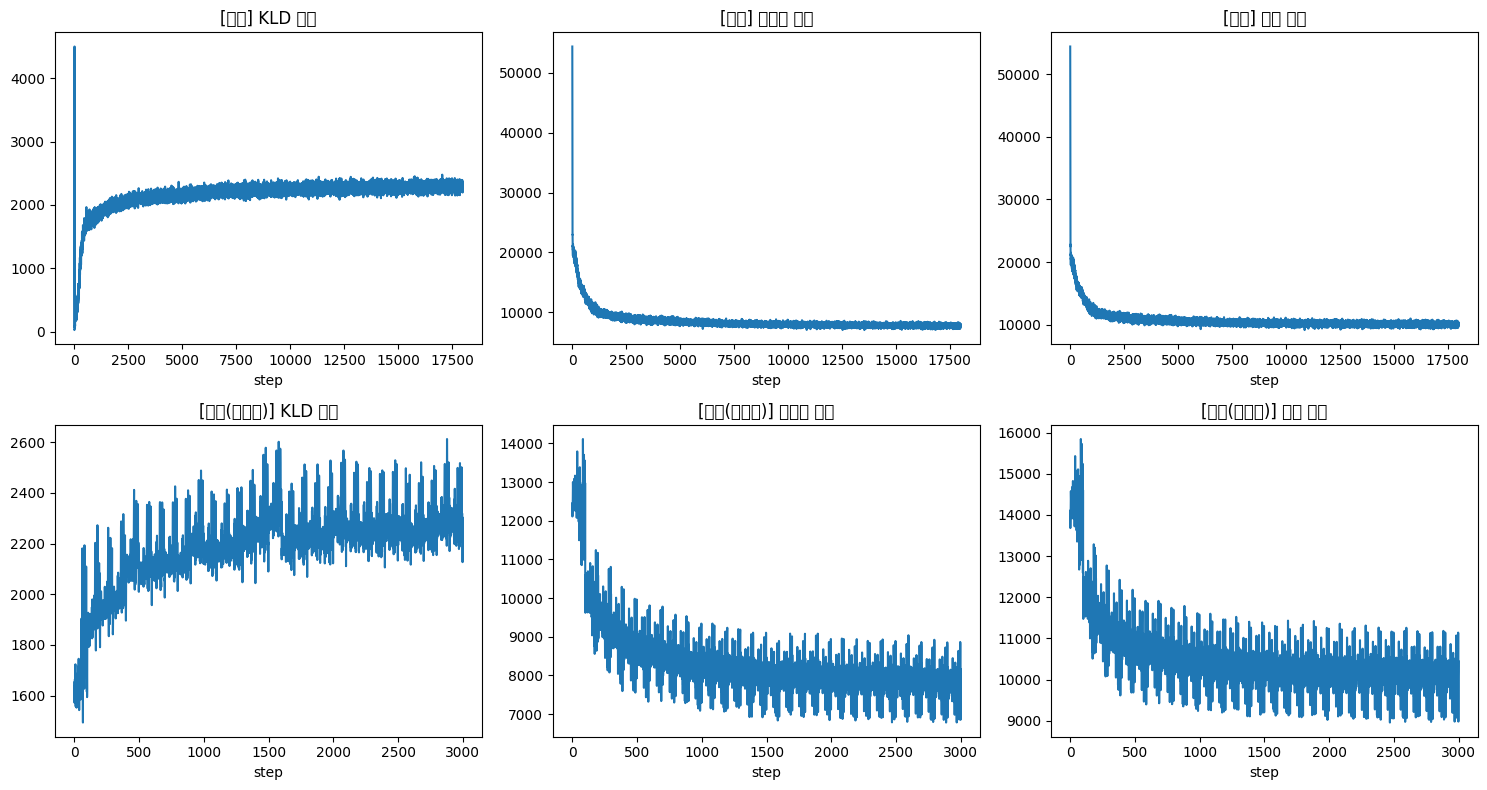

In [12]:
def scalars_to_xy(tag):
    events = ea.Scalars(tag)
    xs = [e.step for e in events]
    ys = [e.value for e in events]
    return xs, ys


fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for row, (split, split_name) in enumerate(zip(["Train", "Test"], ["훈련", "검증(테스트)"])):
    for col, (metric, title) in enumerate(zip(
        ["KL-Divergence", "Reconstruction_Error", "Total_Loss"],
        ["KLD 오차", "재구성 오차", "전체 오차"],
    )):
        ax = axes[row, col]
        xs, ys = scalars_to_xy(f"{split}/{metric}")
        ax.plot(xs, ys)
        ax.set_title(f"[{split_name}] {title}")
        ax.set_xlabel("step")

plt.tight_layout()
plt.show()


그림 13-14~13-16(훈련)이랑 13-17~13-19(검증)에 해당하는 결과다. 훈련·검증 둘 다 KLD랑 재구성 오차가 반비례 관계를 보이면서 전체 오차는 에폭이 지날수록 줄어드는 걸 볼 수 있다. 재구성 오차가 줄어드는 걸 보면 기존 이미지로 새 이미지를 만들어내는 게 잘 되고 있다는 뜻이고, KLD는 계속 커지지 않고 어느 정도에서 수렴하는 걸 보면 $q_\phi(z\mid x^{(i)})$가 $p_\theta(z)$에 가까워지고 있다는 뜻이다.

## 정리

이번 실습으로 오토인코더랑 변형 오토인코더가 코드 레벨에서 뭐가 다른지 확실히 알게 됐다. 그냥 오토인코더는 인코더 출력을 바로 디코더에 넣으면 되는데, 변형 오토인코더는 인코더가 z 자체를 안 내놓고 z 분포의 평균(mean)이랑 로그분산(log_var)을 내놓은 다음 그 분포에서 z를 샘플링해야 한다는 게 진짜 다른 점이었다.

`reparameterization` 함수에서 `z = mean + var * epsilon`처럼 노이즈 epsilon을 밖에서 곱하는 식으로 샘플링을 구현한 이유도(그래야 역전파가 mean, log_var까지 그대로 이어질 수 있으니까) 코드로 직접 보니까, 지난주 논문 리뷰에서 읽었던 재매개변수화 트릭이 실제로는 코드 두세 줄로 끝난다는 게 실감났다. 손실 함수도 재구성 오차(BCE)랑 KLD 두 항을 그냥 더한 것뿐인데, 이 둘이 각각 "복원 잘 하기"랑 "잠재분포를 사전분포에 가깝게 유지하기"라는 다른 목표를 맡고 있다는 게 코드만 봐도 딱 보였다.